In [77]:
# Libraries
library(tidyverse)
library(reshape2)
library(vegan)

*Load shotgun data and summarize to genus*

In [35]:
# Samples
s <- c('OP0.2A','OP0.2B','OP0.2C','OP1.2A','OP1.2B','OP1.2C','OP5.0A','OP5.0B','OP5.0C','OP8.0A','OP8.0B','OP8.0C', 'EN0.2A','EN0.2B','EN0.2C')

# Data
df <- read.delim("GenomeDK_LCA/counts.lca.rarefy.tsv")

# Check potential issues
df %>% select(superkingdom, genus) %>% unique() %>% group_by(genus) %>% count() %>% filter(n > 1)
df %>% filter(genus == "Bacillus") %>% select(superkingdom, genus) %>% unique()

# Correct issue
df <- df %>% mutate(genus = ifelse(superkingdom == 'Eukaryota' & genus == 'Bacillus', 'Bacillus_E', genus))

# Summarize data at the genus level
genus <- df %>% group_by(genus) %>% drop_na(genus) %>% select(s) %>% melt() %>% ungroup() %>% group_by(genus, variable) %>%
 summarise(value = sum(value)) %>% spread(genus, value) %>% rename(sample = variable) %>% as.data.frame()

genus,n
<chr>,<int>
Bacillus,2
NA,5


,superkingdom,genus
,<chr>,<chr>
1,Bacteria,Bacillus
21,Eukaryota,Bacillus


Adding missing grouping variables: `genus`
Using genus as id variables

`summarise()` has grouped output by 'genus'. You can override using the `.groups`
argument.


*PERMANOVA*

In [60]:
# Separate numbers from metadata
data <- genus[,-1]
meta <- data.frame(PoreType = unlist(lapply(s, function(x) gsub("[A-C]", "", x))))

In [62]:
permanova <- adonis2(data ~ PoreType, data = meta, method = "bray", permutations = 999)
permanova

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PoreType,4,2.301097,0.7714468,8.438372,0.002
Residual,10,0.681736,0.2285532,NA,NA
Total,14,2.982833,1.0000000,NA,NA


_Permanova or test of centroids_: The sum of squares shows that most of the variation is explained by the pore type, with a total of 77.14% explained by this variable. There is a 22.85% variation not explained by the pore type. Moreover, the F statistic shows that there is a large difference between pore types (samples) in comparison to within pore types (replicates).

*Beta Dispersion*

In [66]:
# Compute distance matrix
bray_dist <- vegdist(data, method="bray")

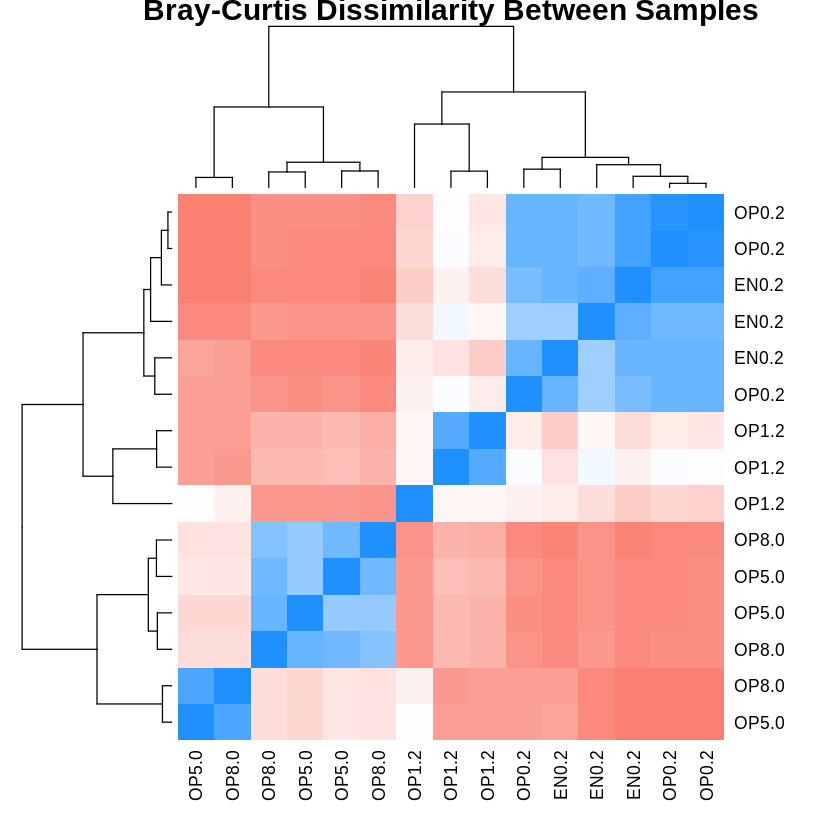

In [104]:
# Visualize distance matrix
distmat <- as.matrix(bray_dist)
ord <- order(meta$PoreType)
distmat <- distmat[ord, ord]
rownames(distmat) <- meta$PoreType[ord]
colnames(distmat) <- meta$PoreType[ord]
heatmap(distmat, scale = "none", col = colorRampPalette(c("dodgerblue", "white", "salmon"))(50), main = "Bray-Curtis Dissimilarity Between Samples")

In [105]:
distmat

,EN0.2,EN0.2,EN0.2,OP0.2,OP0.2,OP0.2,OP1.2,OP1.2,OP1.2,OP5.0,OP5.0,OP5.0,OP8.0,OP8.0,OP8.0
EN0.2,0.00000000,0.1322935,0.1514931,0.07549749,0.08776531,0.1934713,0.5065409,0.5803402,0.6189807,0.8631506,0.8662720,0.9018869,0.8577926,0.8833477,0.9090164
EN0.2,0.13229349,0.0000000,0.2554786,0.17860648,0.17015781,0.2604497,0.4276124,0.4899875,0.5757499,0.8194838,0.8186982,0.8596482,0.8124114,0.8360498,0.8667432
EN0.2,0.15149314,0.2554786,0.0000000,0.14878308,0.15105621,0.1493774,0.5570658,0.6307152,0.5164105,0.8651775,0.8607002,0.7699043,0.8554324,0.8808165,0.7836180
OP0.2,0.07549749,0.1786065,0.1487831,0.00000000,0.03451613,0.1601075,0.4715248,0.5442995,0.6025067,0.8507249,0.8529975,0.8909609,0.8449300,0.8705877,0.8981548
OP0.2,0.08776531,0.1701578,0.1510562,0.03451613,0.00000000,0.1468952,0.4539669,0.5195032,0.5944394,0.8547359,0.8551057,0.8917393,0.8468950,0.8723903,0.8996538
OP0.2,0.19347127,0.2604497,0.1493774,0.16010754,0.14689521,0.0000000,0.4411014,0.5163324,0.5007261,0.8404038,0.8339817,0.7850123,0.8310232,0.8552187,0.7990384
OP1.2,0.50654090,0.4276124,0.5570658,0.47152482,0.45396691,0.4411014,0.0000000,0.1213804,0.4825169,0.7030156,0.6898732,0.7871993,0.6918393,0.7179997,0.8066435
OP1.2,0.58034020,0.4899875,0.6307152,0.54429952,0.51950319,0.5163324,0.1213804,0.0000000,0.4895359,0.7232330,0.7026000,0.7832480,0.7107435,0.7356963,0.7977322
OP1.2,0.61898066,0.5757499,0.5164105,0.60250672,0.59443940,0.5007261,0.4825169,0.4895359,0.0000000,0.8148852,0.8079562,0.4712869,0.8050115,0.8314910,0.5004137
OP5.0,0.86315060,0.8194838,0.8651775,0.85072492,0.85473592,0.8404038,0.7030156,0.7232330,0.8148852,0.0000000,0.2539625,0.5957513,0.1525280,0.2542953,0.5994127


In [107]:
# Compute dispersion
disp <- betadisper(bray_dist, meta$PoreType)
disp

Warning message in betadisper(bray_dist, meta$PoreType):
“some squared distances are negative and changed to zero”



	Homogeneity of multivariate dispersions

Call: betadisper(d = bray_dist, group = meta$PoreType)

No. of Positive Eigenvalues: 10
No. of Negative Eigenvalues: 4

Average distance to median:
  EN0.2   OP0.2   OP1.2   OP5.0   OP8.0 
0.09581 0.05780 0.19324 0.25652 0.24629 

Eigenvalues for PCoA axes:
(Showing 8 of 14 eigenvalues)
   PCoA1    PCoA2    PCoA3    PCoA4    PCoA5    PCoA6    PCoA7    PCoA8 
1.961921 0.615433 0.345937 0.046257 0.031332 0.016419 0.008258 0.007359 

_Betadisper or replicates dispersion_: The results show low dispersion for EN0.2, OP0.2 or OP1.2 while large dispersion for OP5.0 and OP8.0

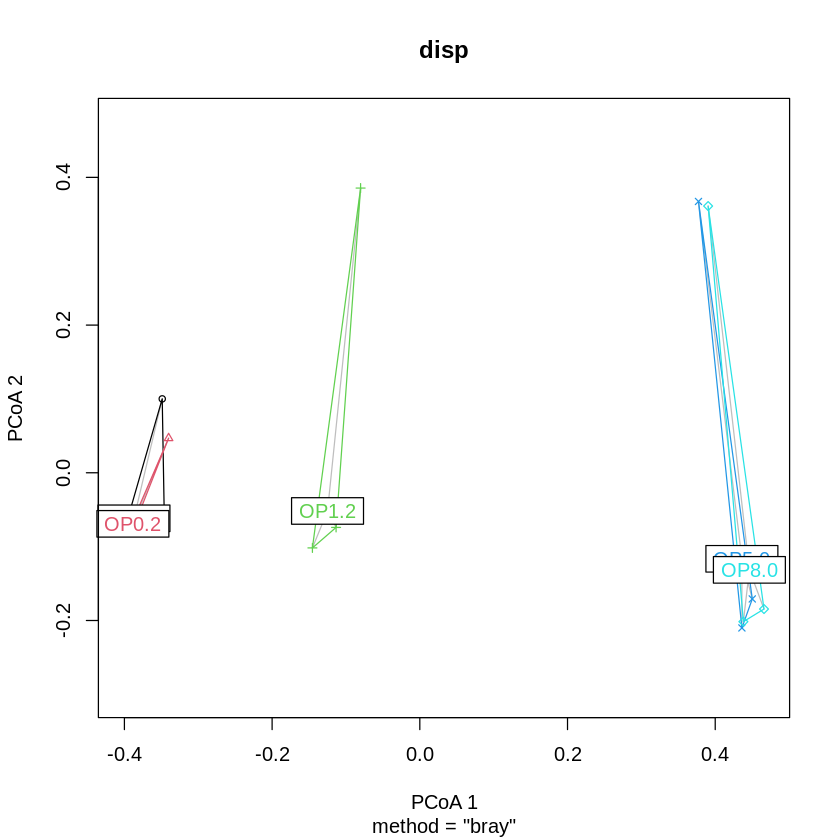

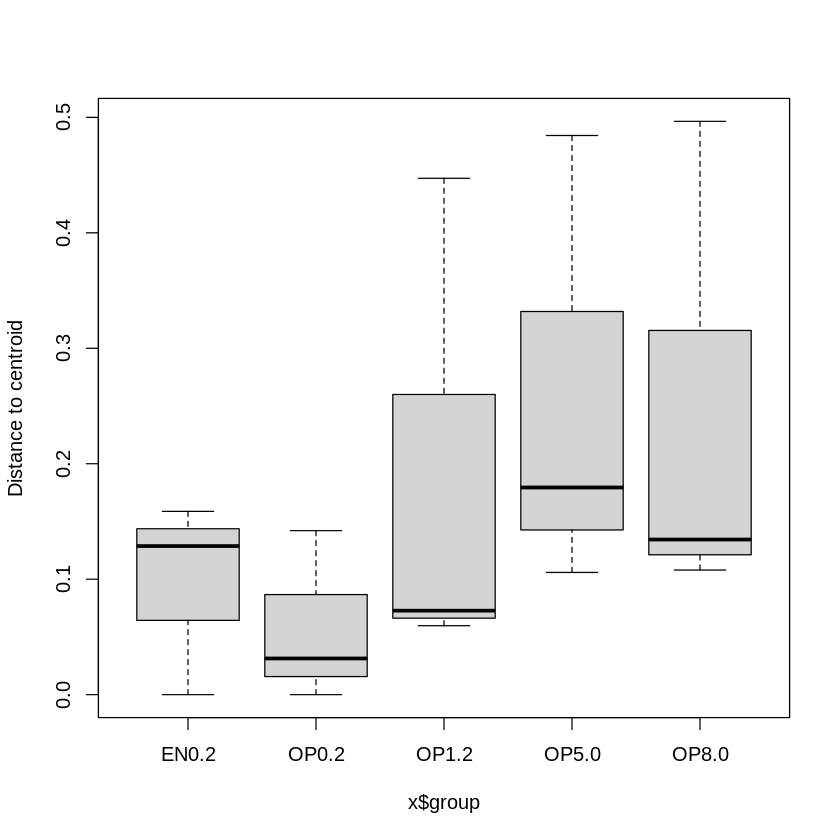

In [111]:
plot(disp)
boxplot(disp)

In [109]:
anova(disp)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,4,0.09581291,0.02395323,0.8064839,0.5484446
Residuals,10,0.29700813,0.02970081,NA,NA


However, the p-value of the anova is largely non-significant. Therefore, we should consider the PERMANOVA results carefully.